In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
url = "https://raw.githubusercontent.com/amankharwal/Website-data/master/unemployment.csv"
df = pd.read_csv(url)

# Quick overview of the dataset
display(df.head())
print("Dataset Shape:", df.shape)
df.info()


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


Dataset Shape: (267, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    267 non-null    object 
 1   Date                                      267 non-null    object 
 2    Frequency                                267 non-null    object 
 3    Estimated Unemployment Rate (%)          267 non-null    float64
 4    Estimated Employed                       267 non-null    int64  
 5    Estimated Labour Participation Rate (%)  267 non-null    float64
 6   Region.1                                  267 non-null    object 
 7   longitude                                 267 non-null    float64
 8   latitude                                  267 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 18.9+ KB


In [3]:
# Check for missing values
print("Missing values in each column:\n", df.isnull().sum())

# Statistical summary of the dataset
display(df.describe())

Missing values in each column:
 Region                                      0
Date                                        0
 Frequency                                  0
 Estimated Unemployment Rate (%)            0
 Estimated Employed                         0
 Estimated Labour Participation Rate (%)    0
Region.1                                    0
longitude                                   0
latitude                                    0
dtype: int64


,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),longitude,latitude
count,267.000000,2.670000e+02,267.000000,267.000000,267.000000
mean,12.236929,1.396211e+07,41.681573,22.826048,80.532425
std,10.803283,1.336632e+07,7.845419,6.270731,5.831738
min,0.500000,1.175420e+05,16.770000,10.850500,71.192400
25%,4.845000,2.838930e+06,37.265000,18.112400,76.085600
50%,9.650000,9.732417e+06,40.390000,23.610200,79.019300
75%,16.755000,2.187869e+07,44.055000,27.278400,85.279900
max,75.850000,5.943376e+07,69.690000,33.778200,92.937600


In [5]:
# Cleaning column names to remove any leading/trailing spaces
df.columns = df.columns.str.strip()
print("Cleaned Columns:", df.columns.tolist())

Cleaned Columns: ['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Region.1', 'longitude', 'latitude']


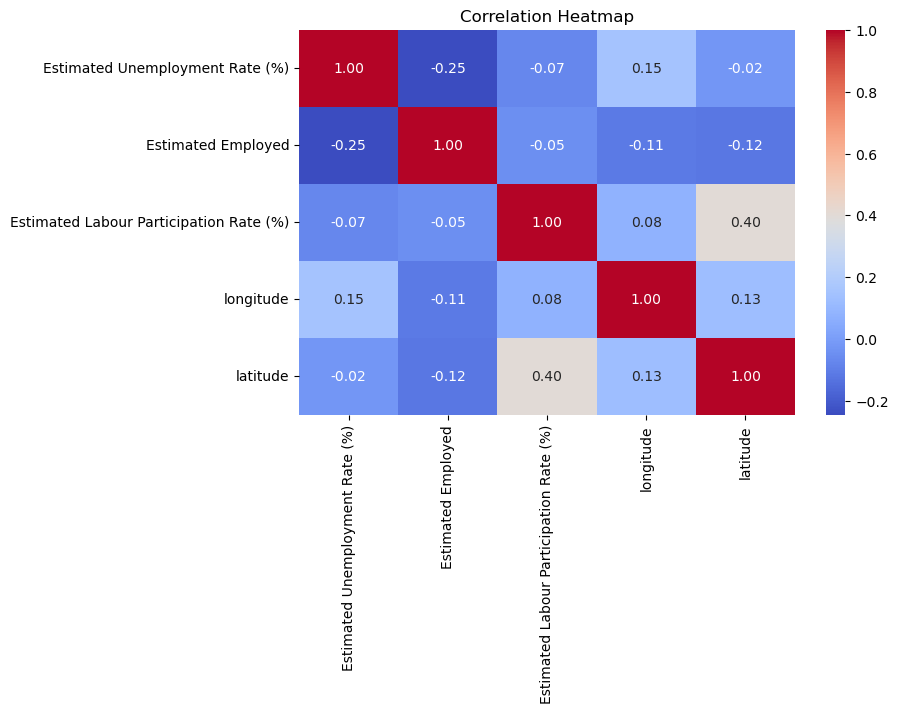

In [6]:
# Correlation Heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

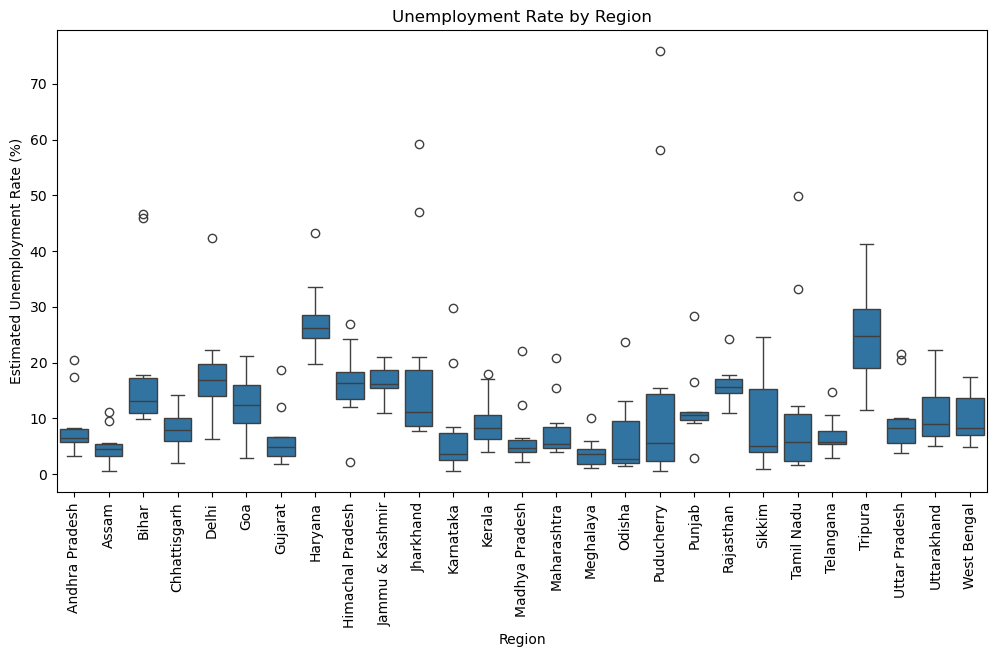

In [7]:
# Region-wise Unemployment Rate (Box Plot)
plt.figure(figsize=(12, 6))
sns.boxplot(x='Region', y='Estimated Unemployment Rate (%)', data=df)
plt.xticks(rotation=90)
plt.title('Unemployment Rate by Region')
plt.show()

C:\Users\deepi\AppData\Local\Temp\ipykernel_15980\2269499721.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_grouped.index, y=df_grouped.values, palette='viridis')


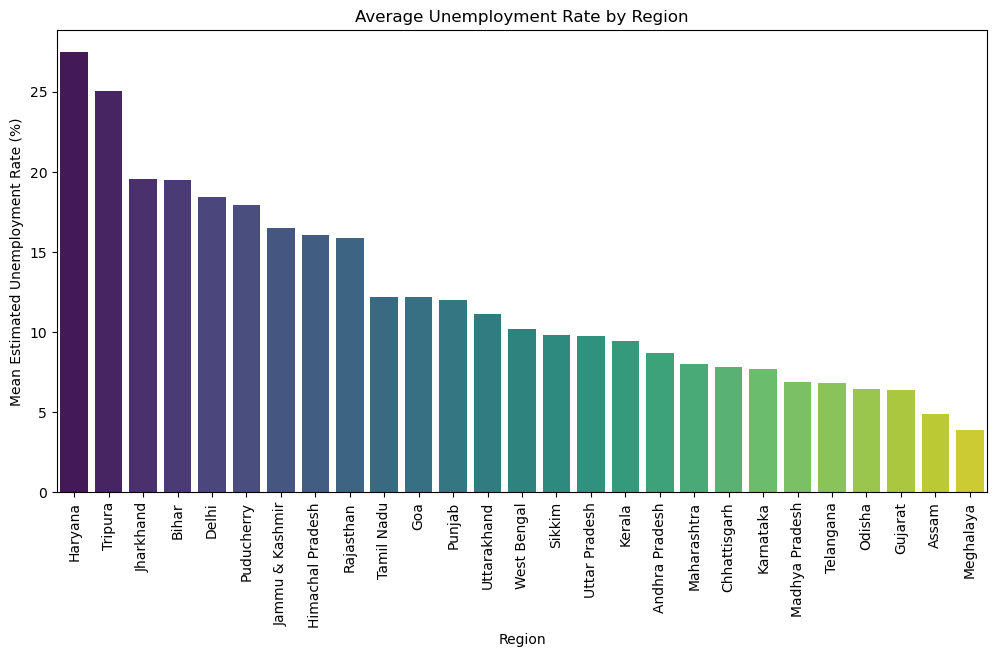

In [8]:
# Average Unemployment Rate by Region
plt.figure(figsize=(12, 6))
df_grouped = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)
sns.barplot(x=df_grouped.index, y=df_grouped.values, palette='viridis')
plt.xticks(rotation=90)
plt.title('Average Unemployment Rate by Region')
plt.ylabel('Mean Estimated Unemployment Rate (%)')
plt.show()

C:\Users\deepi\AppData\Local\Temp\ipykernel_15980\496764830.py:3: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'].str.strip())


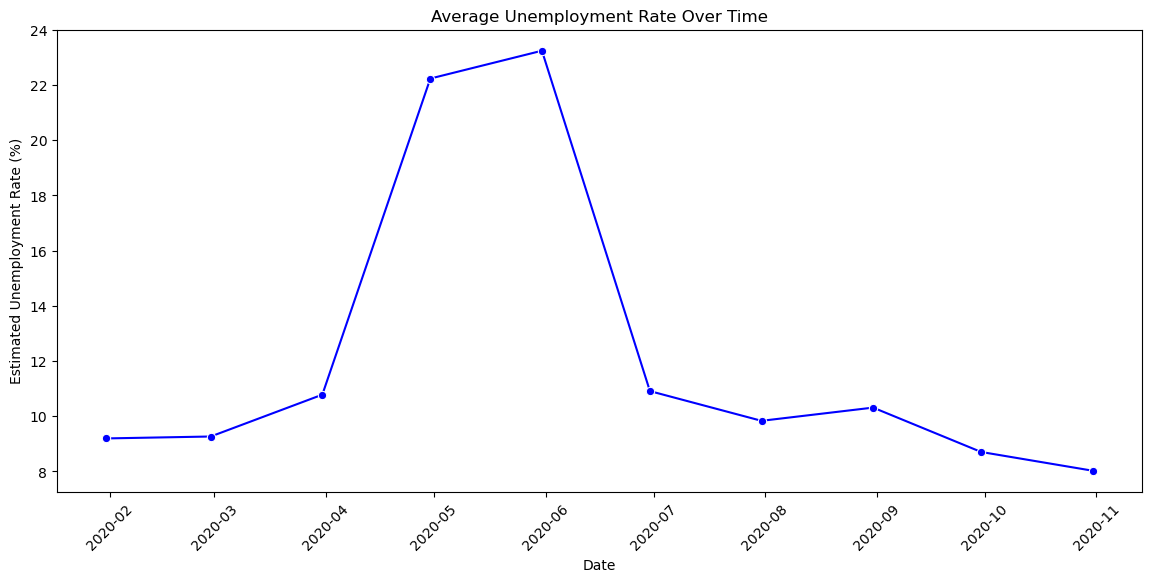

In [9]:
# Unemployment Rate over Time
plt.figure(figsize=(14, 6))
df['Date'] = pd.to_datetime(df['Date'].str.strip())
df_time = df.groupby('Date')['Estimated Unemployment Rate (%)'].mean().reset_index()
sns.lineplot(x='Date', y='Estimated Unemployment Rate (%)', data=df_time, marker='o', color='b')
plt.xticks(rotation=45)
plt.title('Average Unemployment Rate Over Time')
plt.show()